# mlAgent Run Comparison

Compare selected runs across different strategies/architectures. Understand score progression, cost efficiency, and the experiment process.

In [1]:
# ====== CONFIG: edit these to select runs ======

# Option 1: Specify run folder paths directly (takes priority if non-empty)
RUN_PATHS = [
    # "workspace/pack_20260324_173330/run_20260324_152740_board_spooky-author-identification",
    # "workspace/pack_20260324_173330/run_20260324_152636_spooky-author-identification",
]

# Option 2: Auto-discover runs from workspace, with optional filters
WORKSPACE = "workspace"        # root folder containing packs
FILTER_COMPETITION = ""        # e.g. "spooky-author-identification" (empty = all)
FILTER_TIME_AFTER = ""         # e.g. "20260324_150000" (empty = all)
FILTER_TIME_BEFORE = ""        # e.g. "20260324_180000" (empty = all)
FILTER_STRATEGY = ""           # e.g. "board" or "todo" or "" for all

# Display
LOWER_IS_BETTER = True         # set False if your metric is accuracy-like

In [2]:
import json, re
from pathlib import Path
from collections import defaultdict

import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import pandas as pd

sns.set_theme(style="whitegrid")

# ---- Discover runs ----
def parse_run_dir(name):
    """Extract timestamp and competition from run folder name like run_20260324_152740_board_spooky-author-identification"""
    m = re.match(r"run_(\d{8}_\d{6})_(?:(board|todo)_)?(.*)", name)
    if not m:
        return None
    return {"time": m.group(1), "strategy_tag": m.group(2) or "baseline", "competition": m.group(3)}

def discover_runs(workspace):
    found = []
    ws = Path(workspace)
    for pack_dir in sorted(ws.iterdir()):
        if not pack_dir.is_dir() or pack_dir.name.endswith(".tgz"):
            continue
        for run_dir in sorted(pack_dir.iterdir()):
            if not run_dir.is_dir():
                continue
            if (run_dir / "experiment_log.json").exists():
                found.append(run_dir)
    return found

def load_run(run_path):
    run_path = Path(run_path)
    info = parse_run_dir(run_path.name) or {"time": "?", "strategy_tag": "?", "competition": "?"}
    with open(run_path / "experiment_log.json") as f:
        log = json.load(f)
    run = {"path": run_path, "log": log, **info}
    for extra in ["experiment_board.json", "experiment_map.json", "todo_list.json"]:
        p = run_path / extra
        if p.exists():
            with open(p) as f:
                run[extra.replace(".json", "")] = json.load(f)
    return run

# ---- Build run list ----
if RUN_PATHS:
    run_dirs = [Path(p) for p in RUN_PATHS]
else:
    run_dirs = discover_runs(WORKSPACE)

runs = []
for rd in run_dirs:
    r = load_run(rd)
    # Apply filters
    if FILTER_COMPETITION and FILTER_COMPETITION not in r["competition"]:
        continue
    if FILTER_TIME_AFTER and r["time"] < FILTER_TIME_AFTER:
        continue
    if FILTER_TIME_BEFORE and r["time"] > FILTER_TIME_BEFORE:
        continue
    if FILTER_STRATEGY and FILTER_STRATEGY not in r["strategy_tag"]:
        continue
    runs.append(r)

# Generate short labels
for r in runs:
    r["label"] = f"{r['strategy_tag']}_{r['time']}"

palette = sns.color_palette("tab10", max(len(runs), 1))
for i, r in enumerate(runs):
    r["color"] = palette[i]

cum_fn = np.minimum.accumulate if LOWER_IS_BETTER else np.maximum.accumulate

print(f"Loaded {len(runs)} runs:")
for r in runs:
    scores = [rd["grade"]["score"] for rd in r["log"]]
    best = min(scores) if LOWER_IS_BETTER else max(scores)
    print(f"  [{r['label']}] {r['competition']}  |  {len(r['log'])} rounds  |  best={best:.5f}  |  {r['path']}")

Loaded 5 runs:
  [baseline_20260324_001202] spooky-author-identification  |  10 rounds  |  best=0.35322  |  workspace/pack_20260324_110149/run_20260324_001202_spooky-author-identification
  [todo_20260324_003816] spooky-author-identification  |  10 rounds  |  best=0.36848  |  workspace/pack_20260324_110149/run_20260324_003816_todo_spooky-author-identification
  [board_20260324_004029] spooky-author-identification  |  7 rounds  |  best=0.35581  |  workspace/pack_20260324_110149/run_20260324_004029_board_spooky-author-identification
  [baseline_20260324_152636] spooky-author-identification  |  10 rounds  |  best=0.31282  |  workspace/pack_20260324_173330/run_20260324_152636_spooky-author-identification
  [board_20260324_152740] spooky-author-identification  |  10 rounds  |  best=0.31165  |  workspace/pack_20260324_173330/run_20260324_152740_board_spooky-author-identification


## 1. Score Progression

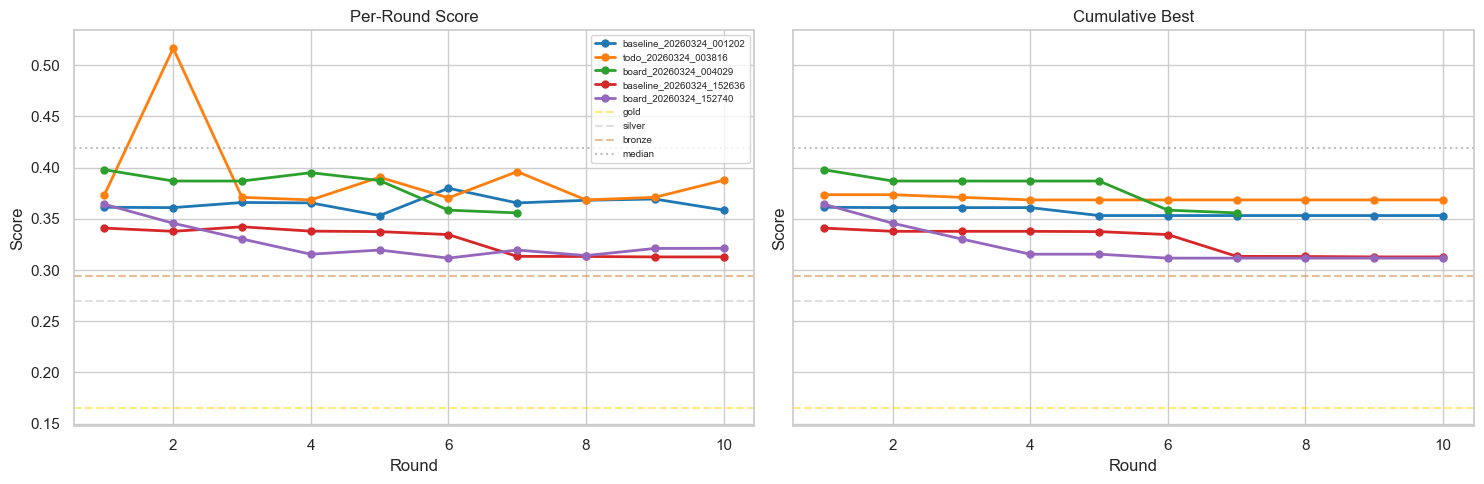

In [3]:
fig, axes = plt.subplots(1, 2, figsize=(15, 5), sharey=True)

for r in runs:
    scores = np.array([rd["grade"]["score"] for rd in r["log"]])
    rounds = np.array([rd["round"] for rd in r["log"]])
    axes[0].plot(rounds, scores, marker="o", label=r["label"], color=r["color"], linewidth=2, markersize=5)
    axes[1].plot(rounds, cum_fn(scores), marker="o", label=r["label"], color=r["color"], linewidth=2, markersize=5)

# Medal thresholds
sample_grade = runs[0]["log"][0]["grade"]
for ax in axes:
    for key, color, ls in [("gold_threshold", "gold", "--"), ("silver_threshold", "silver", "--"),
                            ("bronze_threshold", "#cd7f32", "--"), ("median_threshold", "gray", ":")]:
        if key in sample_grade:
            ax.axhline(y=sample_grade[key], color=color, linestyle=ls, alpha=0.5,
                       label=key.replace("_threshold", "") if ax is axes[0] else None)
    if LOWER_IS_BETTER:
        ax.invert_yaxis()

axes[0].set_title("Per-Round Score")
axes[1].set_title("Cumulative Best")
for ax in axes:
    ax.set_xlabel("Round")
    ax.set_ylabel("Score")
axes[0].legend(fontsize=7, loc="best")
plt.tight_layout()
plt.show()

## 2. Per-Round Improvement

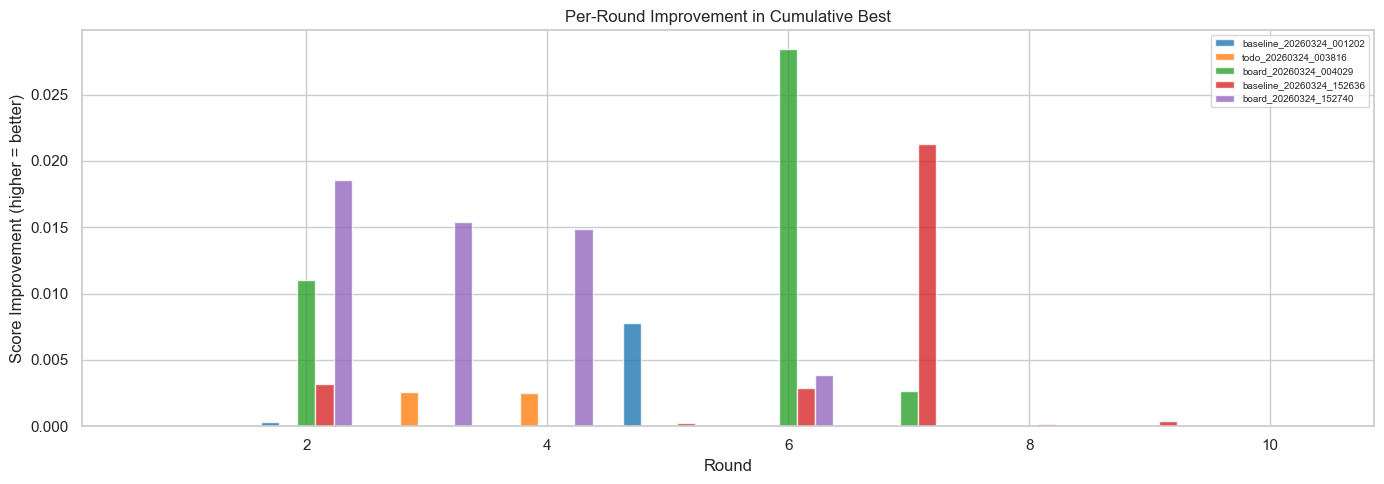

In [4]:
fig, ax = plt.subplots(figsize=(14, 5))
n = len(runs)
bar_w = 0.75 / n

for i, r in enumerate(runs):
    scores = np.array([rd["grade"]["score"] for rd in r["log"]])
    cum_best = cum_fn(scores)
    deltas = np.concatenate([[0.0], np.diff(cum_best)])
    # For lower-is-better, negative delta = improvement, flip sign for display
    improvement = -deltas if LOWER_IS_BETTER else deltas
    rounds = np.array([rd["round"] for rd in r["log"]])
    offset = (i - n/2 + 0.5) * bar_w
    ax.bar(rounds + offset, improvement, width=bar_w, label=r["label"], color=r["color"], alpha=0.8)

ax.axhline(y=0, color="black", linewidth=0.5)
ax.set_xlabel("Round")
ax.set_ylabel("Score Improvement (higher = better)")
ax.set_title("Per-Round Improvement in Cumulative Best")
ax.legend(fontsize=7)
plt.tight_layout()
plt.show()

## 3. Cost & Token Efficiency

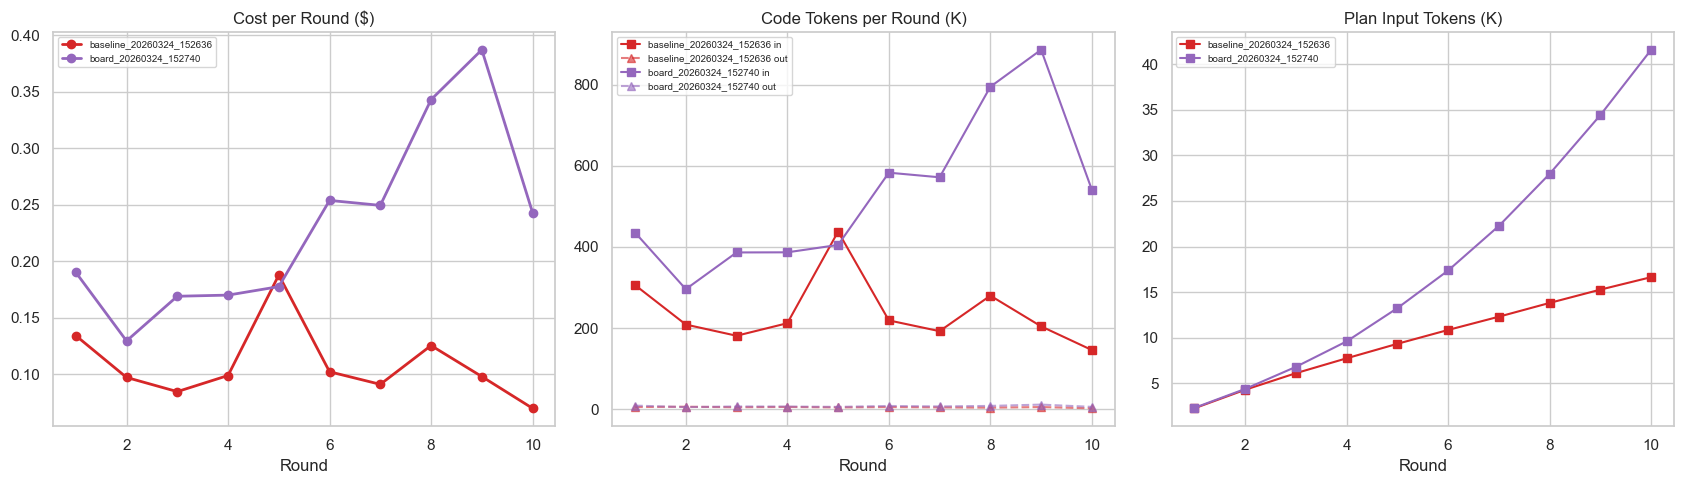

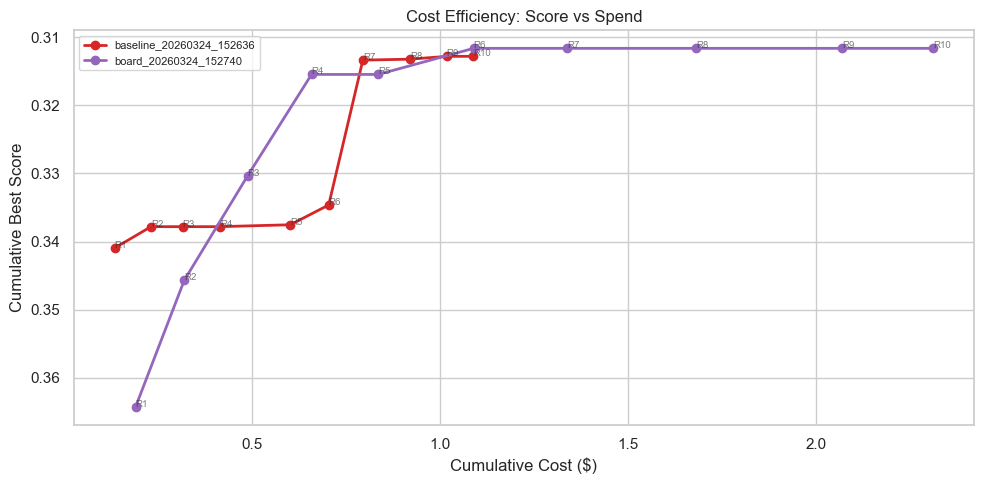


Total cost per run:
  baseline_20260324_152636: $1.09
  board_20260324_152740: $2.31


In [5]:
has_cost = [r for r in runs if "estimated_cost_usd" in r["log"][0]]

if has_cost:
    fig, axes = plt.subplots(1, 3, figsize=(17, 5))

    for r in has_cost:
        rounds = [rd["round"] for rd in r["log"]]
        costs = [rd["estimated_cost_usd"] for rd in r["log"]]
        code_in = [rd["code_tokens"]["input"] / 1000 for rd in r["log"]]
        code_out = [rd["code_tokens"]["output"] / 1000 for rd in r["log"]]
        plan_in = [rd["plan_tokens"]["input"] / 1000 for rd in r["log"]]

        axes[0].plot(rounds, costs, marker="o", label=r["label"], color=r["color"], linewidth=2)
        axes[1].plot(rounds, code_in, marker="s", label=r["label"] + " in", color=r["color"])
        axes[1].plot(rounds, code_out, marker="^", linestyle="--", color=r["color"], alpha=0.6, label=r["label"] + " out")
        axes[2].plot(rounds, plan_in, marker="s", label=r["label"], color=r["color"])

    axes[0].set_title("Cost per Round ($)")
    axes[1].set_title("Code Tokens per Round (K)")
    axes[2].set_title("Plan Input Tokens (K)")
    for ax in axes:
        ax.set_xlabel("Round")
        ax.legend(fontsize=7)
    plt.tight_layout()
    plt.show()

    # Cumulative cost vs score improvement
    fig, ax = plt.subplots(figsize=(10, 5))
    for r in has_cost:
        scores = np.array([rd["grade"]["score"] for rd in r["log"]])
        cum_best = cum_fn(scores)
        cum_cost = np.cumsum([rd["estimated_cost_usd"] for rd in r["log"]])
        ax.plot(cum_cost, cum_best, marker="o", label=r["label"], color=r["color"], linewidth=2)
        # Annotate rounds
        for j, rd in enumerate(r["log"]):
            ax.annotate(f"R{rd['round']}", (cum_cost[j], cum_best[j]), fontsize=7, alpha=0.6)
    ax.set_xlabel("Cumulative Cost ($)")
    ax.set_ylabel("Cumulative Best Score")
    ax.set_title("Cost Efficiency: Score vs Spend")
    if LOWER_IS_BETTER:
        ax.invert_yaxis()
    ax.legend(fontsize=8)
    plt.tight_layout()
    plt.show()

    print("\nTotal cost per run:")
    for r in has_cost:
        total = sum(rd["estimated_cost_usd"] for rd in r["log"])
        print(f"  {r['label']}: ${total:.2f}")
else:
    print("No runs have cost data.")

## 4. Experiment Board / Map: Branch Exploration

In [6]:
board_runs = [r for r in runs if "experiment_board" in r or "experiment_map" in r]

for r in board_runs:
    board = r.get("experiment_board") or r.get("experiment_map", [])
    if not board:
        continue

    df = pd.DataFrame(board)
    scored = df[df["score"].notna()].copy()
    if scored.empty:
        print(f"{r['label']}: no scored experiments in board")
        continue

    branches = scored["branch"].unique()
    bp = sns.color_palette("husl", len(branches))
    bcmap = dict(zip(branches, bp))

    fig, axes = plt.subplots(1, 2, figsize=(16, 5))
    fig.suptitle(f"[{r['label']}] Branch Exploration", fontsize=13)

    # Left: experiments over rounds, colored by branch
    ax = axes[0]
    for b in branches:
        sub = scored[scored["branch"] == b]
        ax.scatter(sub["round"], sub["score"], color=bcmap[b], label=b, s=40, alpha=0.7, edgecolors="white", linewidth=0.5)
    if LOWER_IS_BETTER:
        ax.invert_yaxis()
    ax.set_xlabel("Round")
    ax.set_ylabel("Score")
    ax.set_title("All Experiments by Branch")
    ax.legend(fontsize=6, bbox_to_anchor=(1.02, 1), loc="upper left")

    # Right: best per branch
    ax = axes[1]
    agg_fn = "min" if LOWER_IS_BETTER else "max"
    best = scored.groupby("branch")["score"].agg(agg_fn).sort_values(ascending=LOWER_IS_BETTER)
    colors = [bcmap[b] for b in best.index]
    bars = ax.barh(best.index, best.values, color=colors)
    for bar, score in zip(bars, best.values):
        ax.text(bar.get_width(), bar.get_y() + bar.get_height()/2, f" {score:.4f}", va="center", fontsize=8)
    ax.set_xlabel("Best Score")
    ax.set_title("Best Score per Branch")
    if LOWER_IS_BETTER:
        ax.invert_xaxis()

    plt.tight_layout()
    plt.show()

    # Activity heatmap
    activity = df.groupby(["round", "branch"]).size().reset_index(name="count")
    pivot = activity.pivot(index="branch", columns="round", values="count").fillna(0)
    fig, ax = plt.subplots(figsize=(12, max(3, 0.4 * len(branches))))
    sns.heatmap(pivot, annot=True, fmt=".0f", cmap="YlOrRd", ax=ax)
    ax.set_title(f"[{r['label']}] Branch Activity (entries per round)")
    plt.tight_layout()
    plt.show()

KeyError: 'score'

## 5. Knowledge Base Growth

In [ ]:
has_kb = False
fig, ax = plt.subplots(figsize=(10, 5))
for r in runs:
    sizes = []
    for rd in r["log"]:
        s = rd.get("board_size") or rd.get("map_entries")
        if s is not None:
            sizes.append((rd["round"], s))
    if sizes:
        has_kb = True
        rs, ss = zip(*sizes)
        ax.plot(rs, ss, marker="o", label=r["label"], color=r["color"], linewidth=2)

if has_kb:
    ax.set_xlabel("Round")
    ax.set_ylabel("Board / Map Entries")
    ax.set_title("Knowledge Base Growth Over Rounds")
    ax.legend(fontsize=8)
    plt.tight_layout()
    plt.show()
else:
    plt.close()
    print("No runs have board/map size data.")

## 6. Round-by-Round Process Log

Expand each run's per-round plan and result summary.

In [ ]:
from IPython.display import display, HTML

def truncate(text, max_chars=600):
    if not text:
        return ""
    text = text.strip()
    if len(text) <= max_chars:
        return text
    return text[:max_chars] + "..."

for r in runs:
    rows = []
    for rd in r["log"]:
        g = rd["grade"]
        medal = "gold" if g.get("gold_medal") else "silver" if g.get("silver_medal") else \
                "bronze" if g.get("bronze_medal") else "above_median" if g.get("above_median") else "-"
        rows.append({
            "Round": rd["round"],
            "Score": f"{g['score']:.5f}",
            "Valid": g.get("valid_submission", True),
            "Medal": medal,
            "Plan (truncated)": truncate(rd.get("plan", ""), 300),
            "Result Summary (truncated)": truncate(rd.get("coding_summary", ""), 400),
        })
    df_log = pd.DataFrame(rows)
    print(f"\n{'='*80}")
    print(f"  {r['label']}  |  {r['competition']}")
    print(f"{'='*80}")
    display(df_log.style.set_properties(**{"text-align": "left", "white-space": "pre-wrap"}).set_table_styles(
        [{"selector": "th", "props": [("text-align", "left")]}]
    ))

## 7. Approach Keywords Comparison

In [ ]:
keywords = [
    "tfidf", "tf-idf", "logistic", "svm", "nb-svm", "naive bayes",
    "stacking", "ensemble", "blending", "calibration", "glove", "embedding",
    "xgboost", "lightgbm", "random forest", "sgd", "svd",
    "feature engineering", "n-gram", "meta-learner",
    "oof", "temperature scaling", "pruning"
]

kw_data = {}
for r in runs:
    counts = defaultdict(int)
    for rd in r["log"]:
        text = (rd.get("coding_summary", "") + " " + rd.get("plan", "")).lower()
        for kw in keywords:
            if kw in text:
                counts[kw] += 1
    kw_data[r["label"]] = dict(counts)

df_kw = pd.DataFrame(kw_data).fillna(0).astype(int)
df_kw = df_kw.loc[df_kw.sum(axis=1) > 0]
df_kw = df_kw.loc[df_kw.sum(axis=1).sort_values(ascending=True).index]  # sort ascending for barh

if not df_kw.empty:
    fig, ax = plt.subplots(figsize=(12, max(4, 0.4 * len(df_kw))))
    df_kw.plot(kind="barh", ax=ax, stacked=True, color=[r["color"] for r in runs if r["label"] in df_kw.columns])
    ax.set_xlabel("Mention Count (across all rounds)")
    ax.set_title("Approach Keywords in Plans & Summaries")
    ax.legend(fontsize=7, bbox_to_anchor=(1.02, 1), loc="upper left")
    plt.tight_layout()
    plt.show()
else:
    print("No keyword matches found.")

## 8. Summary Table

In [ ]:
rows = []
for r in runs:
    scores = np.array([rd["grade"]["score"] for rd in r["log"]])
    cum_best = cum_fn(scores)
    best_idx = int(np.argmin(scores)) if LOWER_IS_BETTER else int(np.argmax(scores))
    costs = [rd.get("estimated_cost_usd", 0) for rd in r["log"]]
    total_cost = sum(costs)

    rows.append({
        "Run": r["label"],
        "Competition": r["competition"],
        "Strategy": r["strategy_tag"],
        "Rounds": len(r["log"]),
        "R1 Score": scores[0],
        "Best Score": cum_best[-1],
        "Best @ Round": r["log"][best_idx]["round"],
        "Improvement": abs(scores[0] - cum_best[-1]),
        "Total Cost ($)": f"${total_cost:.2f}" if total_cost > 0 else "-",
        "Cost/Round ($)": f"${total_cost/len(r['log']):.2f}" if total_cost > 0 else "-",
    })

df_summary = pd.DataFrame(rows)
highlight_col = "Best Score"
if LOWER_IS_BETTER:
    styled = df_summary.style.highlight_min(subset=[highlight_col], color="#c6efce")
else:
    styled = df_summary.style.highlight_max(subset=[highlight_col], color="#c6efce")
styled